<a href="https://colab.research.google.com/github/cvinushareddy/Data-science-projects/blob/main/Week_7_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

C VINUSHA REDDY

1CR22IS036


# **House Price  Prediction(Regression)**

### **Problem Statement**

The real estate industry often needs accurate estimation of property prices based on various house characteristics. In this task, the goal is to build a Machine Learning regression model that predicts the price of a house using features such as house size, number of bedrooms, number of bathrooms, lot size, garage size, neighborhood quality, and the year the house was built.Students are required to analyze the dataset, perform data preprocessing, apply feature engineering techniques, train multiple regression models, and evaluate their performance to identify the best model for predicting house prices

### **Objective**

The objective of this task is to:
- Understand and explore the housing dataset.
- Perform *data preprocessing* including handling missing values, duplicates, and outliers.
- Conduct *Exploratory Data Analysis (EDA)* to identify patterns and relationships in the data.
- Apply *encoding*, *log transformation*, and *feature scaling* where necessary.
- Train multiple *regression algorithms* to predict house prices.
- Evaluate and compare model performance using appropriate *evaluation metrics*.

### **1.Import Required Libraries**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

###**2.Load the Dataset**

In [ ]:
data = pd.read_csv('house_price_regression_dataset.csv')
data

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


### **Domain Analysis**

The descriptions of the variables based on the house price dataset:

**1. Square_Footage**
- Description: Total area of the house measured in square feet. It represents the size of the property.
- Type: Continuous numerical variable.

**2. Num_Bedrooms**
- Description: Number of bedrooms available in the house.
- Type: Discrete numerical variable.

**3. Num_Bathrooms**
- Description: Number of bathrooms in the house.
- Type: Discrete numerical variable.

**4. Year_Built**
- Description: The year in which the house was constructed.
- Type: Discrete numerical variable.

**5. Lot_Size**
- Description: Total land area on which the house is built.
- Type: Continuous numerical variable.

**6. Garage_Size**
- Description: Capacity of the garage in terms of number of vehicles it can accommodate.
- Type: Discrete numerical variable.

**7. Neighborhood_Quality**
- Description: Rating of the neighborhood based on factors like safety, infrastructure, and amenities.
- Type: Discrete numerical variable (scale: 1 to 10).

**8. House_Price**
- Description: The selling price of the house. This is the target variable to be predicted.
- Type: Continuous numerical variable.

### **3. Check the Dataset**

In [ ]:
# shape : gives number of rows and columns
data.shape

(1000, 8)

In [ ]:
# head: print first 5 rows
data.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [ ]:
# tail : print last 5 rows
data.tail()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
995,3261,4,1,1978,2.165110,2,10,701493.997069
996,3179,1,2,1999,2.977123,1,10,683723.160704
997,2606,4,2,1962,4.055067,0,2,572024.023634
998,4723,5,2,1950,1.930921,0,7,964865.298639
999,3268,4,2,1983,3.108790,2,2,742599.253332


In [ ]:
# info: memory usage
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [ ]:
# print all columns
data.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

In [ ]:
# check the data type
data.dtypes

,0
Square_Footage,int64
Num_Bedrooms,int64
Num_Bathrooms,int64
Year_Built,int64
Lot_Size,float64
Garage_Size,int64
Neighborhood_Quality,int64
House_Price,float64


In [ ]:
# print numerical columns
num_col= data.select_dtypes(include=['int64','float64'])
num_col


,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


In [ ]:
# statiscal report for numerical column
data.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


### **4.Handle Missing values**

In [ ]:
data.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


Clearly no missing values.

### **5.Remove Duplicate values**

**Check for duplicates**

In [ ]:
# duplicates : repeated values
data.duplicated().sum()

np.int64(0)

Clearly no duplicates values.

###**6.Perform Univariate Analysis**


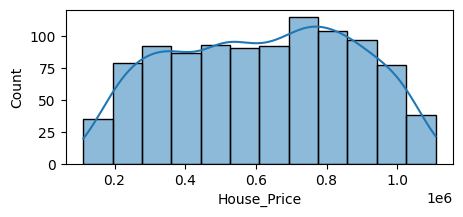

In [ ]:

# Histogram - House Price
plt.figure(figsize=(5,2))
sns.histplot(data, x='House_Price', kde=True)
plt.show()

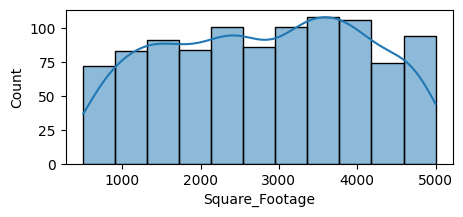

In [ ]:
# Histogram - Square Footage
plt.figure(figsize=(5,2))
sns.histplot(data, x='Square_Footage', kde=True)
plt.show()


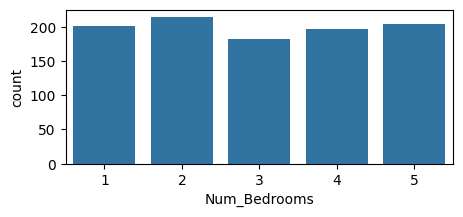

In [ ]:
# Count Plot - Number of Bedrooms
plt.figure(figsize=(5,2))
sns.countplot(x='Num_Bedrooms', data=data)
plt.show()


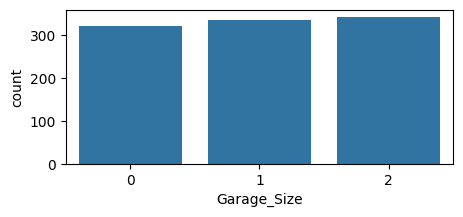

In [ ]:
# Count Plot - Garage Size
plt.figure(figsize=(5,2))
sns.countplot(x='Garage_Size', data=data)
plt.show()

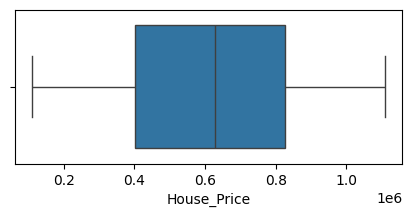

In [ ]:
# Box Plot - House Price
plt.figure(figsize=(5,2))
sns.boxplot(x='House_Price', data=data)
plt.show()

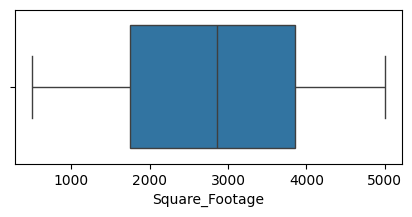

In [ ]:
# Box Plot - Square Footage
plt.figure(figsize=(5,2))
sns.boxplot(x='Square_Footage', data=data)
plt.show()

### **7.Perform Bivariate Analysis**

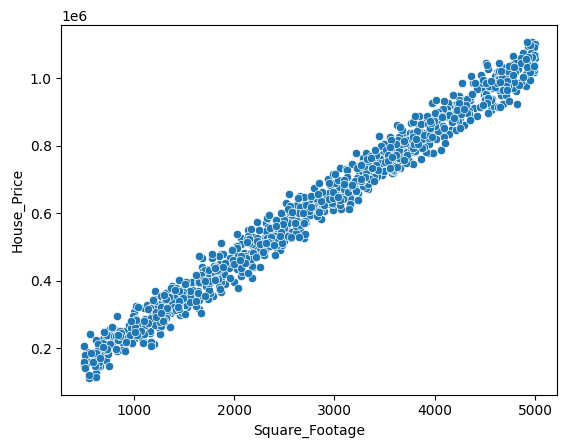

In [ ]:
# Square Footage vs House Price
sns.scatterplot(x='Square_Footage', y='House_Price', data=data)
plt.show()

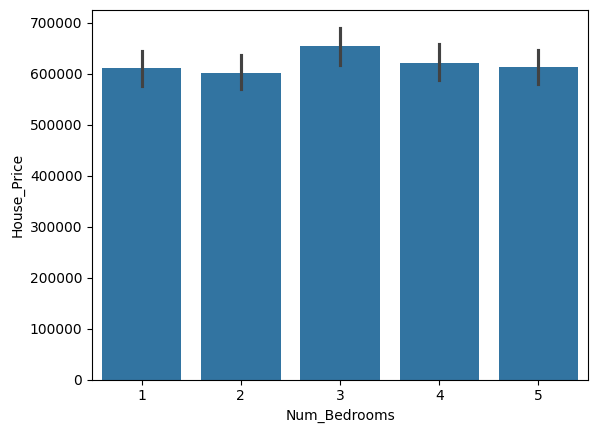

In [ ]:
# Number of Bedrooms vs House Price
sns.barplot(x='Num_Bedrooms', y='House_Price', data=data)
plt.show()


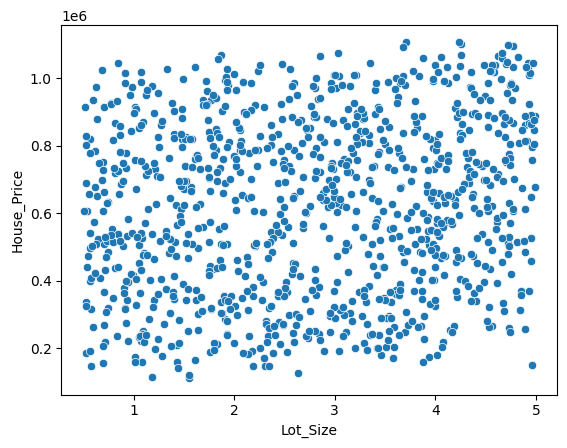

In [ ]:
# Lot Size vs House Price
sns.scatterplot(x='Lot_Size', y='House_Price', data=data)
plt.show()

## **8.Generate Correlation Heatmap**

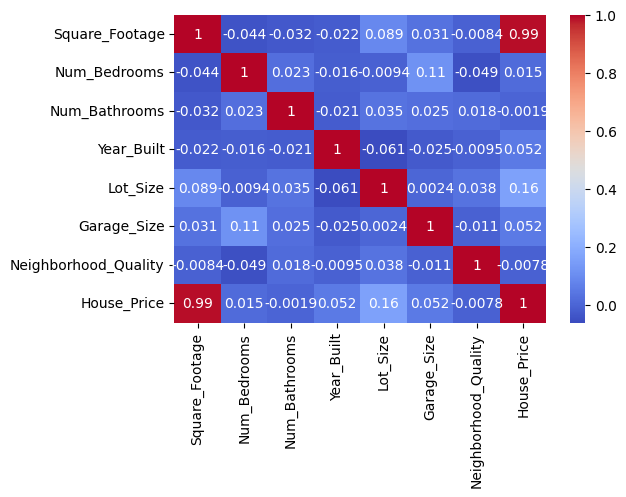

In [ ]:

plt.figure(figsize=(6,4))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

### **9.Handling Outliers**

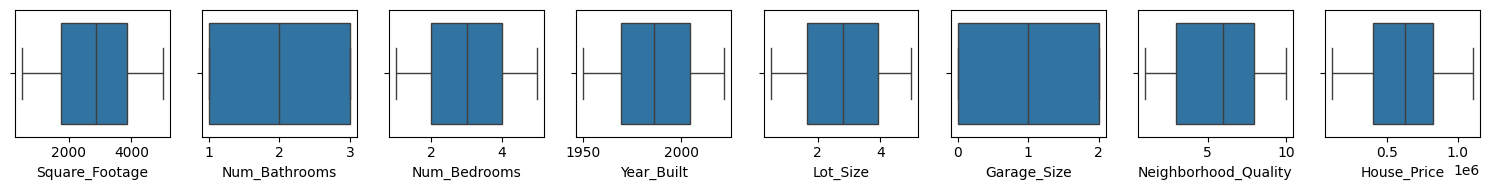

In [ ]:
fig, ax = plt.subplots(1, 8, figsize=(15, 2))
sns.boxplot(data,x='Square_Footage',ax=ax[0])
sns.boxplot(data,x='Num_Bathrooms',ax=ax[1])
sns.boxplot(data,x='Num_Bedrooms',ax=ax[2])
sns.boxplot(data,x='Year_Built',ax=ax[3])
sns.boxplot(data,x='Lot_Size',ax=ax[4])
sns.boxplot(data,x='Garage_Size',ax=ax[5])
sns.boxplot(data,x='Neighborhood_Quality',ax=ax[6])
sns.boxplot(data,x='House_Price',ax=ax[7])

plt.tight_layout()


No significant outliers are observed from the boxplot visualization

### **10.Apply Encoding (if categorical variables exist**

In [ ]:
# Checking for categorical columns
data.select_dtypes(include=['object']).columns


Index([], dtype='object')

No categorical columns found


Hence, encoding is not required

### **11.Apply Log Transformation**

In [ ]:
data['House_Price'] = np.log(data['House_Price'])


### **12.Separate Features and Target Variables**

In [ ]:
X = data.drop('House_Price', axis=1)
y = data['House_Price']


### **13.Perform Train-Test-Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


### **14.Apply feature scaling**

In [ ]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### **15.Training Regression Models**

In [ ]:
# Linear Regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)


# KNN Regression
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)


### **16.Evaluate Model Using**


*   MAE(Mean Absolute Error)
*   MSE(Mean Squared Error)


*   RMSE(Root Mean Squared Error0
*   MAPE

*   R^2 Score
*   Adjusted r2








In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)
    n = len(y_test)
    p = X_test.shape[1]
    adj_r2 = 1 - (1-r2)*(n-1)/(n-p-1)

    print("MAE(Mean Absolute Error):", mae)
    print("MSE(Mean Squared Error):", mse)
    print("RMSE(Root Mean Squared Error):", rmse)
    print("MAPE:", mape)
    print("R2 Score:", r2)
    print("Adjusted R2:", adj_r2)


# Linear Regression Results
print("Linear Regression Results")
evaluate(y_test, y_pred_lr)


# KNN Regression Results
print("\nKNN Regression Results")
evaluate(y_test, y_pred_knn)

Linear Regression Results
MAE(Mean Absolute Error): 0.09078292767761202
MSE(Mean Squared Error): 0.012923132230239545
RMSE(Root Mean Squared Error): 0.11367995527022143
MAPE: 0.695987033882357
R2 Score: 0.9462493474741257
Adjusted R2: 0.9442896882674532

KNN Regression Results
MAE(Mean Absolute Error): 0.13352458657348393
MSE(Mean Squared Error): 0.03275242370493434
RMSE(Root Mean Squared Error): 0.18097630702645676
MAPE: 1.0316078365784032
R2 Score: 0.8637741907627683
Adjusted R2: 0.8588076248009943
